# Tarea 2: Aprendizaje Distribuido para Computer Vision
## LEAD University — 2026

| Campo | Valor |
|---|---|
| **Estudiante** | Jason Jesús Barrantes Sánchez |
| **Profesor** | Johansell Villalobos Cubillo |
| **Fecha** | 2026-06-03 |
| **Dataset** | Wonders of the World Image Classification (Kaggle) |
| **Frameworks** | JAX · Flax NNX · Optax |

---
Este notebook implementa un clasificador de imágenes de maravillas del mundo usando **JAX** y **Flax NNX**.  
Se exploran: tamaño de lote, tasa de aprendizaje, tamaño de red, optimización de hiperparámetros y precisión numérica.

## Sección 1: Configuración del Entorno

In [ ]:
# ── 1.1 Instalación ─────────────────────────────────────────────────────────
#
# INSTRUCCIONES:
#   1. Ejecuta SOLO esta celda
#   2. Espera que termine
#   3. Ve a: Entorno de ejecución → Reiniciar sesión  (NO uses Ejecutar todo)
#   4. Después del reinicio, ejecuta todo desde la celda 1.2 hacia abajo
#

# JAX con CUDA12 — arregla el error de incompatibilidad PJRT
!pip install -q "jax[cuda12_pip]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html

# Flax NNX, Optax y Kaggle (sin --upgrade para no romper dependencias de Colab)
!pip install -q flax optax kaggle

print("=" * 55)
print("  ✓ Instalación completa.")
print("  → Ahora ve a: Entorno de ejecución → Reiniciar sesión")
print("  → Luego ejecuta desde la celda 1.2 hacia abajo")
print("=" * 55)


  ✓ Instalación completa.
  → Ahora ve a: Entorno de ejecución → Reiniciar sesión
  → Luego ejecuta desde la celda 1.2 hacia abajo


In [ ]:
# ── 1.2 Importaciones ────────────────────────────────────────────────────────
import os, time, gc, warnings, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import jax
import jax.numpy as jnp
from jax import lax
from flax import nnx
import optax

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"#f8f9fa","font.size":11})
sns.set_palette("husl")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print(f"JAX    : {jax.__version__}")
print(f"Flax   : {__import__('flax').__version__}")
print(f"Optax  : {optax.__version__}")
print("✓ Librerías importadas")

JAX    : 0.7.2
Flax   : 0.11.2
Optax  : 0.2.8
✓ Librerías importadas


In [ ]:
# ── 1.3 Verificación del Acelerador ─────────────────────────────────────────
# ¡TOMAR CAPTURA DE PANTALLA DE ESTA CELDA PARA EL INFORME!
print("=" * 55)
print("  DISPOSITIVOS JAX")
print("=" * 55)
devices = jax.devices()
print(f"  Dispositivos : {devices}")
print(f"  Cantidad     : {jax.device_count()}")
print(f"  Backend      : {jax.default_backend()}")

if jax.default_backend() in ("gpu", "tpu"):
    print(f"\n  ✓ Acelerador activo: {jax.default_backend().upper()}")
    for i, d in enumerate(devices):
        print(f"    [{i}] {d}")
else:
    print("\n  ⚠ Solo CPU. Ir a: Entorno de ejecución → Cambiar tipo → GPU")

x = jnp.ones((4, 4))
print(f"\n  ✓ Prueba JAX: dot(ones,ones)[0,0] = {jnp.dot(x,x)[0,0]:.0f}")

  DISPOSITIVOS JAX
  Dispositivos : [CudaDevice(id=0)]
  Cantidad     : 1
  Backend      : gpu

  ✓ Acelerador activo: GPU
    [0] cuda:0

  ✓ Prueba JAX: dot(ones,ones)[0,0] = 4


## Sección 2: Dataset — Wonders of the World

> **Fuente**: [kaggle.com/datasets/balabaskar/wonders-of-the-world-image-classification](https://www.kaggle.com/datasets/balabaskar/wonders-of-the-world-image-classification)

**Pasos para configurar Kaggle:**
1. Ir a kaggle.com → Settings → API → **Create New Token** (genera un token `KGAT_...`)
2. Pegar el token en la variable `KAGGLE_TOKEN` de la celda siguiente

In [ ]:
# ── 2.1 Configuración de Kaggle y descarga del dataset ───────────────────────
import os
from pathlib import Path

# ┌─────────────────────────────────────────────────────────────────────────┐
# │  PEGA AQUÍ TU TOKEN DE KAGGLE  (formato: KGAT_xxxxxxxxxxxxxxxxxxxxxxxx) │
KAGGLE_TOKEN = "KGAT_a5b7a7111334c75f2929cfff4447540d"
# └─────────────────────────────────────────────────────────────────────────┘

assert KAGGLE_TOKEN.startswith("KGAT_") and len(KAGGLE_TOKEN) > 10, \
    "❌ Reemplaza KAGGLE_TOKEN con tu token real (empieza con KGAT_)"

os.environ["KAGGLE_API_TOKEN"] = KAGGLE_TOKEN
print("✓ Token de Kaggle configurado")

# Descargar y extraer
DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True)

!kaggle datasets download -d balabaskar/wonders-of-the-world-image-classification \
        -p ./data --unzip

print("\n📁 Contenido de ./data:")
for item in sorted(DATA_DIR.iterdir()):
    print(f"  {item.name}/")

✓ Token de Kaggle configurado
Dataset URL: https://www.kaggle.com/datasets/balabaskar/wonders-of-the-world-image-classification
License(s): CC0-1.0
100% 432M/432M [00:07<00:00, 62.6MB/s]


📁 Contenido de ./data:
  Wonders of World/
  wonders_of_world_images.csv/


In [ ]:
# ── 2.2 Detección automática del directorio raíz ─────────────────────────────
EXTENSIONS = {".jpg",".jpeg",".png",".JPG",".JPEG",".PNG"}

def find_dataset_root(base: Path) -> Path:
    for root, dirs, _ in os.walk(base):
        rp = Path(root)
        for d in dirs:
            imgs = [f for f in (rp/d).iterdir()
                    if f.is_file() and f.suffix in EXTENSIONS]
            if imgs:
                return rp
    return base

DATASET_ROOT = find_dataset_root(DATA_DIR)
print(f"✓ Raíz del dataset: {DATASET_ROOT}")

classes = sorted([d.name for d in DATASET_ROOT.iterdir() if d.is_dir()])
class_counts = {}
total = 0
print(f"\n📊 Clases ({len(classes)}):")
print("-" * 35)
for cls in classes:
    n = len([f for f in (DATASET_ROOT/cls).iterdir()
             if f.is_file() and f.suffix in EXTENSIONS])
    class_counts[cls] = n
    total += n
    print(f"  {cls:<25}: {n:>5}")
print(f"  {'TOTAL':<25}: {total:>5}")
NUM_CLASSES = len(classes)

✓ Raíz del dataset: data/Wonders of World/Wonders of World

📊 Clases (12):
-----------------------------------
  burj_khalifa             :   390
  chichen_itza             :   340
  christ_the_reedemer      :   323
  eiffel_tower             :   391
  great_wall_of_china      :   392
  machu_pichu              :   393
  pyramids_of_giza         :   372
  roman_colosseum          :   394
  statue_of_liberty        :   238
  stonehenge               :   204
  taj_mahal                :   158
  venezuela_angel_falls    :   251
  TOTAL                    :  3846


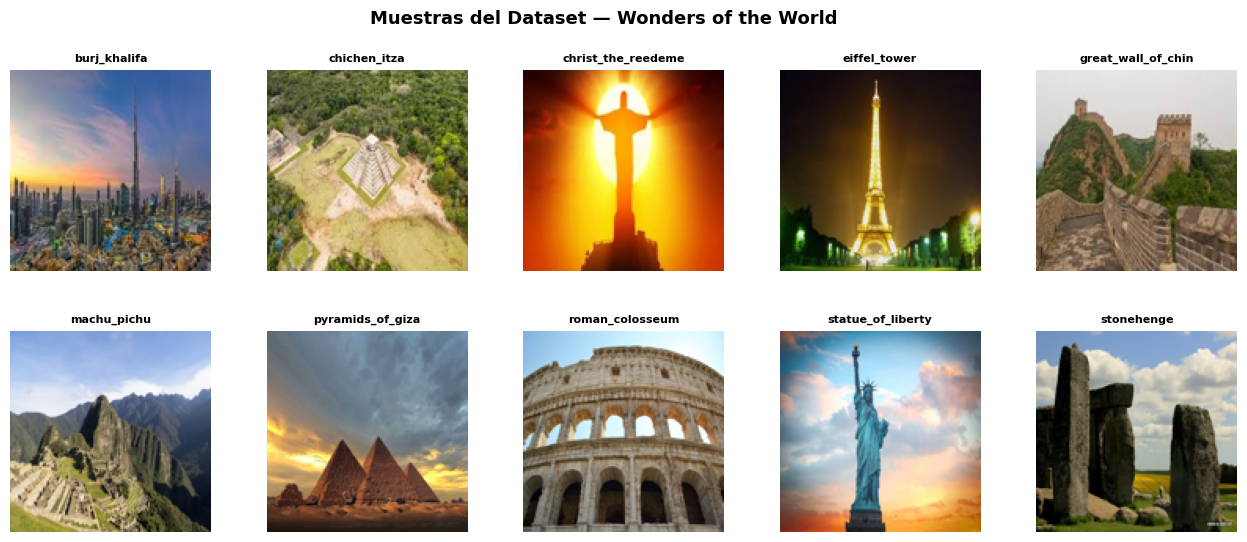

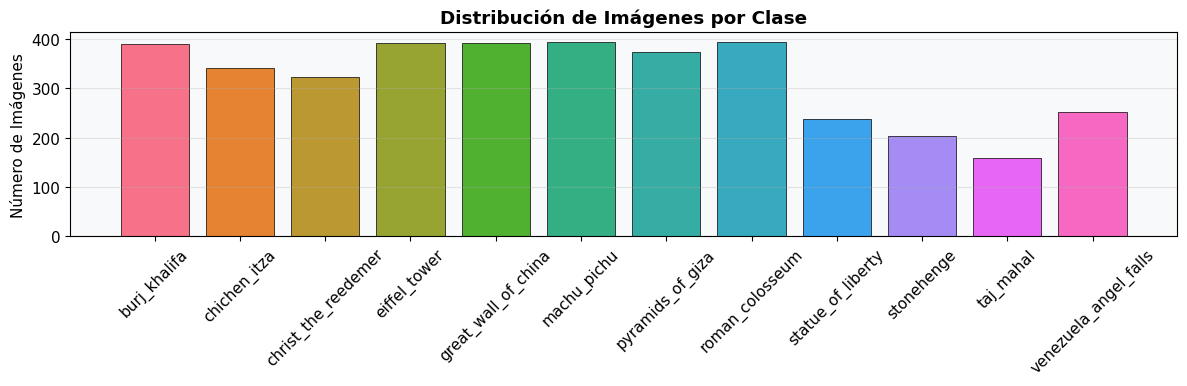

In [ ]:
# ── 2.3 Visualización de muestras ────────────────────────────────────────────
n_show = min(len(classes), 10)
fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(2, 5, figure=fig, hspace=0.3)

for i, cls in enumerate(classes[:n_show]):
    imgs = [f for f in (DATASET_ROOT/cls).iterdir()
            if f.suffix.lower() in {".jpg",".jpeg",".png"}]
    if not imgs:
        continue
    ax = fig.add_subplot(gs[i//5, i%5])
    ax.imshow(Image.open(imgs[0]).convert("RGB").resize((128,128)))
    ax.set_title(cls[:18], fontsize=8, fontweight="bold")
    ax.axis("off")

plt.suptitle("Muestras del Dataset — Wonders of the World", fontsize=13, fontweight="bold")
plt.savefig("dataset_samples.png", dpi=150, bbox_inches="tight")
plt.show()

# Distribución de clases
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(class_counts.keys(), class_counts.values(),
       color=sns.color_palette("husl", len(class_counts)),
       edgecolor="black", linewidth=0.5)
ax.set_title("Distribución de Imágenes por Clase", fontweight="bold")
ax.set_ylabel("Número de Imágenes")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Sección 3: Preprocesamiento y Pipeline de Datos

In [ ]:
# ── 3.1 Clase WondersDataset ─────────────────────────────────────────────────
IMG_SIZE   = 64   # Resolución: 64×64 px
CHANNELS   = 3    # RGB
EXTENSIONS = {".jpg",".jpeg",".png",".JPG",".JPEG",".PNG"}

class WondersDataset:
    """
    Pipeline de datos: split train/val/test, normalización y augmentation.
    - Train: 70% | Val: 15% | Test: 15%
    - Normalización: (pixel/255 - mean) / std  (media y std del train set)
    """

    def __init__(self, root_dir, img_size=64,
                 val_split=0.15, test_split=0.15, seed=42):
        self.root_dir  = Path(root_dir)
        self.img_size  = img_size
        self.classes   = sorted([d.name for d in self.root_dir.iterdir() if d.is_dir()])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.num_classes  = len(self.classes)

        all_paths, all_labels = [], []
        for cls in self.classes:
            for f in (self.root_dir/cls).iterdir():
                if f.is_file() and f.suffix in EXTENSIONS:
                    all_paths.append(str(f))
                    all_labels.append(self.class_to_idx[cls])

        rng = np.random.RandomState(seed)
        idx = rng.permutation(len(all_paths))
        all_paths  = [all_paths[i]  for i in idx]
        all_labels = [all_labels[i] for i in idx]

        n      = len(all_paths)
        n_val  = int(n * val_split)
        n_test = int(n * test_split)
        n_tr   = n - n_val - n_test

        self.train_paths  = all_paths[:n_tr]
        self.train_labels = all_labels[:n_tr]
        self.val_paths    = all_paths[n_tr:n_tr+n_val]
        self.val_labels   = all_labels[n_tr:n_tr+n_val]
        self.test_paths   = all_paths[n_tr+n_val:]
        self.test_labels  = all_labels[n_tr+n_val:]

        print(f"✓ Dataset — {self.num_classes} clases")
        print(f"  Train:{len(self.train_paths)}  Val:{len(self.val_paths)}  Test:{len(self.test_paths)}")
        self._compute_stats()

    def _compute_stats(self, n=500):
        imgs = []
        for p in self.train_paths[:min(n, len(self.train_paths))]:
            try:
                im = Image.open(p).convert("RGB").resize((self.img_size,)*2, Image.BILINEAR)
                imgs.append(np.array(im, dtype=np.float32)/255.0)
            except Exception:
                continue
        imgs = np.stack(imgs)
        self.mean = imgs.mean(axis=(0,1,2))
        self.std  = imgs.std(axis=(0,1,2)) + 1e-8
        print(f"  Media:{self.mean.round(3)}  Std:{self.std.round(3)}")

    def load_image(self, path, augment=False):
        img = Image.open(path).convert("RGB").resize((self.img_size,)*2, Image.BILINEAR)
        img = np.array(img, dtype=np.float32) / 255.0
        if augment:
            if np.random.random() > 0.5:
                img = img[:, ::-1, :]  # flip horizontal
            img = np.clip(img * np.random.uniform(0.85, 1.15), 0, 1)  # brillo
        return ((img - self.mean) / self.std).astype(np.float32)

    def get_batches(self, split="train", batch_size=32, shuffle=True, augment=False):
        pm = {"train":(self.train_paths, self.train_labels),
              "val":  (self.val_paths,   self.val_labels),
              "test": (self.test_paths,  self.test_labels)}
        paths, labels = pm[split]
        paths, labels = paths[:], labels[:]
        if shuffle:
            p = np.random.permutation(len(paths))
            paths  = [paths[i]  for i in p]
            labels = [labels[i] for i in p]
        for start in range(0, len(paths), batch_size):
            bp, bl = paths[start:start+batch_size], labels[start:start+batch_size]
            imgs, lbs = [], []
            for p, l in zip(bp, bl):
                try:
                    imgs.append(self.load_image(p, augment=augment and split=="train"))
                    lbs.append(l)
                except Exception:
                    continue
            if imgs:
                yield {"image": np.array(imgs, dtype=np.float32),
                       "label": np.array(lbs,  dtype=np.int32)}

dataset = WondersDataset(DATASET_ROOT, img_size=IMG_SIZE)
NUM_CLASSES = dataset.num_classes

# Verificar batch
batch = next(dataset.get_batches("train", batch_size=8))
print(f"\n✓ Batch de prueba — imágenes:{batch['image'].shape}  etiquetas:{batch['label']}")

✓ Dataset — 12 clases
  Train:2694  Val:576  Test:576
  Media:[0.471 0.492 0.492]  Std:[0.263 0.246 0.286]

✓ Batch de prueba — imágenes:(8, 64, 64, 3)  etiquetas:[1 0 5 5 9 5 6 4]


## Sección 4: Modelo CNN con Flax NNX

### Arquitectura

```
Input (batch, 64, 64, 3)
  ↓  Conv(3→F,  3×3, SAME) → BatchNorm → ReLU → MaxPool(2×2)
  ↓  Conv(F→2F, 3×3, SAME) → BatchNorm → ReLU → MaxPool(2×2)
  ↓  Conv(2F→4F,3×3, SAME) → BatchNorm → ReLU → GlobalAvgPool
  ↓  Dense(4F→D) → ReLU → Dropout(0.3)
  ↓  Dense(D→C) → Logits
```
**F** = num_filters · **D** = dense_size · **C** = num_classes

In [ ]:
# ── 4.1 Implementación CNN con Flax NNX ──────────────────────────────────────

def max_pool2d(x, window=(2,2), strides=(2,2), padding="VALID"):
    """Max pooling usando jax.lax (compatible con todas las versiones de Flax NNX)."""
    return lax.reduce_window(
        x, init_value=-jnp.inf, computation=lax.max,
        window_dimensions=(1,) + window + (1,),
        window_strides=(1,) + strides + (1,),
        padding=padding,
    )


class CNN(nnx.Module):
    """
    Red Neuronal Convolucional — Flax NNX.

    Args
    ----
    num_classes  : número de clases de salida
    num_filters  : filtros base (los bloques usan F, 2F, 4F filtros)
    dense_size   : neuronas en la capa densa oculta
    dropout_rate : tasa de dropout
    rngs         : nnx.Rngs
    """

    def __init__(self, num_classes, num_filters=64, dense_size=256,
                 dropout_rate=0.3, rngs=None):
        F = num_filters
        # Bloque 1
        self.conv1 = nnx.Conv(3,   F,   kernel_size=(3,3), strides=(1,1), padding="SAME", rngs=rngs)
        self.bn1   = nnx.BatchNorm(F,   rngs=rngs)
        # Bloque 2
        self.conv2 = nnx.Conv(F,   F*2, kernel_size=(3,3), strides=(1,1), padding="SAME", rngs=rngs)
        self.bn2   = nnx.BatchNorm(F*2, rngs=rngs)
        # Bloque 3
        self.conv3 = nnx.Conv(F*2, F*4, kernel_size=(3,3), strides=(1,1), padding="SAME", rngs=rngs)
        self.bn3   = nnx.BatchNorm(F*4, rngs=rngs)
        # Clasificador
        self.dense1    = nnx.Linear(F*4,      dense_size,  rngs=rngs)
        self.dense_out = nnx.Linear(dense_size, num_classes, rngs=rngs)
        self.dropout   = nnx.Dropout(rate=dropout_rate, rngs=rngs)

    def __call__(self, x, use_running_average=False):
        """
        Forward pass.
        use_running_average=False → entrenamiento (actualiza BatchNorm stats)
        use_running_average=True  → evaluación    (usa stats acumuladas)
        """
        # Bloque 1 — Conv → BN → ReLU → MaxPool
        x = self.conv1(x)
        x = self.bn1(x, use_running_average=use_running_average)
        x = jax.nn.relu(x)
        x = max_pool2d(x)
        # Bloque 2
        x = self.conv2(x)
        x = self.bn2(x, use_running_average=use_running_average)
        x = jax.nn.relu(x)
        x = max_pool2d(x)
        # Bloque 3 — Conv → BN → ReLU → GlobalAvgPool
        x = self.conv3(x)
        x = self.bn3(x, use_running_average=use_running_average)
        x = jax.nn.relu(x)
        x = x.mean(axis=(1, 2))   # Global Average Pooling → (batch, 4F)
        # Clasificador
        x = self.dense1(x)
        x = jax.nn.relu(x)
        x = self.dropout(x)
        x = self.dense_out(x)
        return x


# ── Prueba de arquitectura ────────────────────────────────────────────────────
_m = CNN(num_classes=NUM_CLASSES, num_filters=32, dense_size=128, rngs=nnx.Rngs(SEED))
_x = jnp.ones((4, IMG_SIZE, IMG_SIZE, 3))
_y = _m(_x, use_running_average=True)
print(f"✓ Forward pass: {_x.shape} → {_y.shape}")
del _m

✓ Forward pass: (4, 64, 64, 3) → (4, 12)


## Sección 5: Funciones de Entrenamiento y Visualización

In [ ]:
# ── 5.1 Paso de entrenamiento con JAX JIT + diferenciación automática ─────────

@nnx.jit
def train_step(model, optimizer, images, labels):
    """Un paso de entrenamiento: calcula gradientes y actualiza parámetros."""
    def loss_fn(model):
        logits = model(images, use_running_average=False)
        loss   = optax.softmax_cross_entropy_with_integer_labels(logits, labels).mean()
        return loss, logits

    # Diferenciación automática — calcula pérdida Y gradientes en un solo pase
    grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
    (loss, logits), grads = grad_fn(model)

    # Descenso de gradiente (Adam actualiza θ ← θ − η·∇L)
    optimizer.update(model, grads)

    acc = jnp.mean(jnp.argmax(logits, axis=-1) == labels)
    return loss, acc


@nnx.jit
def eval_step(model, images, labels):
    """Paso de evaluación (sin actualización de parámetros)."""
    logits = model(images, use_running_average=True)
    loss   = optax.softmax_cross_entropy_with_integer_labels(logits, labels).mean()
    acc    = jnp.mean(jnp.argmax(logits, axis=-1) == labels)
    return loss, acc


def run_epoch(model, optimizer, dataset, batch_size, split="train", augment=False):
    losses, accs = [], []
    training = (split == "train")
    for batch in dataset.get_batches(split=split, batch_size=batch_size,
                                     shuffle=training, augment=augment):
        imgs = jnp.array(batch["image"])
        lbs  = jnp.array(batch["label"])
        loss, acc = (train_step(model, optimizer, imgs, lbs) if training
                     else eval_step(model, imgs, lbs))
        losses.append(float(loss)); accs.append(float(acc))
    return (np.mean(losses) if losses else float("nan"),
            np.mean(accs)   if accs   else 0.0)


def train_and_evaluate(config, dataset, verbose=True):
    """Entrenamiento + evaluación completos con la configuración dada."""
    num_epochs    = config.get("num_epochs",    20)
    batch_size    = config.get("batch_size",    64)
    learning_rate = config.get("learning_rate", 1e-3)
    num_filters   = config.get("num_filters",   64)
    dense_size    = config.get("dense_size",    256)
    augment       = config.get("augment",       True)

    if verbose:
        print(f"\n{'='*60}")
        print(f"  lr={learning_rate:.0e}  batch={batch_size}  "
              f"filtros={num_filters}  dense={dense_size}  épocas={num_epochs}")
        print(f"{'='*60}")

    model     = CNN(num_classes=dataset.num_classes, num_filters=num_filters,
                    dense_size=dense_size, rngs=nnx.Rngs(SEED))
    optimizer = nnx.Optimizer(model, optax.adam(learning_rate), wrt=nnx.Param)

    hist = {"train_loss":[],"train_acc":[],"val_loss":[],"val_acc":[],"epoch_times":[]}
    t0   = time.time()
    log_every = max(1, num_epochs // 10)

    for epoch in range(num_epochs):
        te = time.time()
        tr_l, tr_a = run_epoch(model, optimizer, dataset, batch_size, "train", augment)
        vl_l, vl_a = run_epoch(model, optimizer, dataset, batch_size, "val")
        et = time.time() - te
        hist["train_loss"].append(tr_l); hist["train_acc"].append(tr_a)
        hist["val_loss"].append(vl_l);   hist["val_acc"].append(vl_a)
        hist["epoch_times"].append(et)
        if verbose and ((epoch+1) % log_every == 0 or epoch == 0):
            print(f"  Época {epoch+1:3d}/{num_epochs} | "
                  f"Train loss={tr_l:.4f} acc={tr_a:.4f} | "
                  f"Val loss={vl_l:.4f} acc={vl_a:.4f} | {et:.1f}s")

    total_time = time.time() - t0
    ts_l, ts_a = run_epoch(model, optimizer, dataset, batch_size, "test")
    throughput  = len(dataset.train_paths) * num_epochs / total_time

    results = {**config, "history":hist, "total_time":total_time,
               "avg_epoch_time":np.mean(hist["epoch_times"]),
               "test_loss":ts_l, "test_acc":ts_a,
               "best_val_acc":max(hist["val_acc"]), "throughput":throughput}

    if verbose:
        print(f"\n  ✓ Tiempo: {total_time:.1f}s | Avg/época: {np.mean(hist['epoch_times']):.2f}s")
        print(f"  ✓ Test → loss={ts_l:.4f}  acc={ts_a:.4f}")
        print(f"  ✓ Throughput: {throughput:.0f} imgs/s")
    return results

print("✓ Funciones de entrenamiento listas")

✓ Funciones de entrenamiento listas


In [ ]:
# ── 5.2 Funciones de Visualización ───────────────────────────────────────────

def plot_curves(history, title, save=None):
    ep  = range(1, len(history["train_loss"])+1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(ep, history["train_loss"], "b-o", lw=2, ms=3, label="Train")
    axes[0].plot(ep, history["val_loss"],   "r--s",lw=2, ms=3, label="Val")
    axes[0].set(title="Curva de Pérdida", xlabel="Época", ylabel="Cross-Entropy Loss")
    axes[0].legend(); axes[0].grid(True, alpha=.3)

    axes[1].plot(ep, [a*100 for a in history["train_acc"]], "b-o", lw=2, ms=3, label="Train")
    axes[1].plot(ep, [a*100 for a in history["val_acc"]],   "r--s",lw=2, ms=3, label="Val")
    axes[1].set(title="Curva de Exactitud", xlabel="Época", ylabel="Exactitud (%)", ylim=(0,100))
    axes[1].legend(); axes[1].grid(True, alpha=.3)

    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save: plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()


def plot_comparison(results_list, x_key, x_label, title, save=None):
    labels = [str(r[x_key]) for r in results_list]
    cols   = sns.color_palette("husl", len(results_list))
    metrics = [
        ("Exactitud Test (%)",  [r["test_acc"]*100    for r in results_list]),
        ("Throughput (imgs/s)", [r["throughput"]        for r in results_list]),
        ("Tiempo Total (s)",    [r["total_time"]        for r in results_list]),
        ("Avg Época (s)",       [r["avg_epoch_time"]    for r in results_list]),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    for ax, (metric, vals) in zip(axes.flatten(), metrics):
        bars = ax.bar(labels, vals, color=cols, edgecolor="black", lw=.5)
        ax.set(title=metric, xlabel=x_label); ax.grid(True, alpha=.3, axis="y")
        for b, v in zip(bars, vals):
            ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.02,
                    f"{v:.1f}", ha="center", fontsize=9)
    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save: plt.savefig(save, dpi=150, bbox_inches="tight")
    plt.show()


def make_table(results_list, keys, rename=None):
    rows = []
    for r in results_list:
        row = {k: r.get(k) for k in keys}
        row["Test Acc (%)"]  = f"{r['test_acc']*100:.2f}"
        row["Val Acc (%)"]   = f"{r['best_val_acc']*100:.2f}"
        row["Total (s)"]     = f"{r['total_time']:.1f}"
        row["Avg/época (s)"] = f"{r['avg_epoch_time']:.2f}"
        row["Throughput"]    = f"{r['throughput']:.0f}"
        rows.append(row)
    df = pd.DataFrame(rows)
    if rename: df = df.rename(columns=rename)
    return df

print("✓ Funciones de visualización listas")

✓ Funciones de visualización listas


## Sección 6: Entrenamiento Base (Baseline)

| Hiperparámetro | Valor |
|---|---|
| Batch Size | 64 |
| Learning Rate | 1 × 10⁻³ |
| Filtros | 64 |
| Dense | 256 |
| Épocas | 30 |

In [ ]:
BASE_CONFIG = {"num_epochs":30,"batch_size":64,"learning_rate":1e-3,
               "num_filters":64,"dense_size":256,"augment":True}

print("Entrenamiento base...")
base_res = train_and_evaluate(BASE_CONFIG, dataset, verbose=True)

Entrenamiento base...

  lr=1e-03  batch=64  filtros=64  dense=256  épocas=30
  Época   1/30 | Train loss=1.9748 acc=0.3285 | Val loss=2.4403 acc=0.1302 | 33.1s
  Época   3/30 | Train loss=1.4969 acc=0.4969 | Val loss=2.3226 acc=0.2622 | 22.6s
  Época   6/30 | Train loss=1.1453 acc=0.6171 | Val loss=1.9486 acc=0.3854 | 22.7s
  Época   9/30 | Train loss=0.9912 acc=0.6864 | Val loss=1.5647 acc=0.5000 | 22.2s
  Época  12/30 | Train loss=0.8586 acc=0.7042 | Val loss=1.9860 acc=0.4201 | 22.6s
  Época  15/30 | Train loss=0.7610 acc=0.7472 | Val loss=1.7541 acc=0.5208 | 22.8s
  Época  18/30 | Train loss=0.7036 acc=0.7642 | Val loss=1.0466 acc=0.6597 | 23.1s
  Época  21/30 | Train loss=0.7003 acc=0.7684 | Val loss=0.9845 acc=0.6562 | 22.9s
  Época  24/30 | Train loss=0.5258 acc=0.8297 | Val loss=0.9105 acc=0.6927 | 22.9s
  Época  27/30 | Train loss=0.5136 acc=0.8391 | Val loss=0.9460 acc=0.7118 | 23.6s
  Época  30/30 | Train loss=0.4113 acc=0.8640 | Val loss=0.8805 acc=0.7222 | 22.9s

  ✓ Tiem

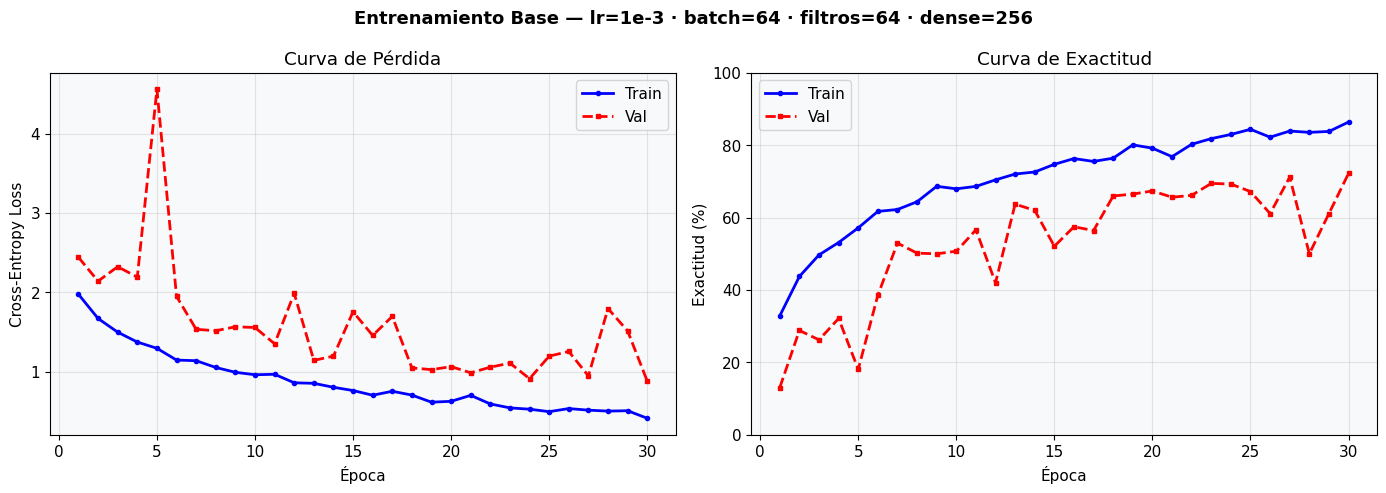

Test Acc: 73.96%  |  Mejor Val Acc: 72.22%


In [ ]:
plot_curves(base_res["history"],
            "Entrenamiento Base — lr=1e-3 · batch=64 · filtros=64 · dense=256",
            save="curvas_base.png")
print(f"Test Acc: {base_res['test_acc']*100:.2f}%  |  "
      f"Mejor Val Acc: {base_res['best_val_acc']*100:.2f}%")

## Sección 7: Experimento 6.1 — Impacto del Tamaño de Lote

**Batch sizes evaluados: {32, 64, 128}**

| Hipótesis | |
|---|---|
| BS pequeño | Mayor ruido en gradiente, posible mejor generalización, menor throughput |
| BS grande | Gradiente más estable, mayor throughput, puede requerir ajuste de lr |

In [ ]:
BATCH_SIZES  = [32, 64, 128]
BATCH_EPOCHS = 20
batch_results = []

for bs in BATCH_SIZES:
    cfg = {**BASE_CONFIG, "batch_size": bs, "num_epochs": BATCH_EPOCHS}
    res = train_and_evaluate(cfg, dataset, verbose=True)
    batch_results.append(res)
    gc.collect()

print("\n✓ Experimentos de batch size completados")


  lr=1e-03  batch=32  filtros=64  dense=256  épocas=20
  Época   1/20 | Train loss=1.9714 acc=0.3286 | Val loss=2.1116 acc=0.2743 | 31.1s
  Época   2/20 | Train loss=1.6415 acc=0.4545 | Val loss=1.9244 acc=0.3611 | 23.3s
  Época   4/20 | Train loss=1.3203 acc=0.5599 | Val loss=1.5584 acc=0.4722 | 23.4s
  Época   6/20 | Train loss=1.1639 acc=0.6012 | Val loss=1.9402 acc=0.4028 | 23.3s
  Época   8/20 | Train loss=0.9891 acc=0.6674 | Val loss=1.8685 acc=0.4375 | 23.3s
  Época  10/20 | Train loss=0.9156 acc=0.6920 | Val loss=1.0707 acc=0.6354 | 22.7s
  Época  12/20 | Train loss=0.7849 acc=0.7425 | Val loss=1.3566 acc=0.6094 | 23.1s
  Época  14/20 | Train loss=0.7303 acc=0.7637 | Val loss=1.0409 acc=0.6719 | 23.1s
  Época  16/20 | Train loss=0.6501 acc=0.7846 | Val loss=1.9816 acc=0.5052 | 23.2s
  Época  18/20 | Train loss=0.5757 acc=0.8142 | Val loss=0.8178 acc=0.7361 | 23.4s
  Época  20/20 | Train loss=0.5379 acc=0.8140 | Val loss=0.9314 acc=0.7118 | 23.1s

  ✓ Tiempo: 470.8s | Avg/época

📊 TABLA — IMPACTO DEL TAMAÑO DE LOTE
 Batch Size Test Acc (%) Val Acc (%) Total (s) Avg/época (s) Throughput
         32        74.31       73.61     470.8         23.54        114
         64        73.09       69.97     461.5         23.08        117
        128        52.66       62.19     461.7         23.08        117


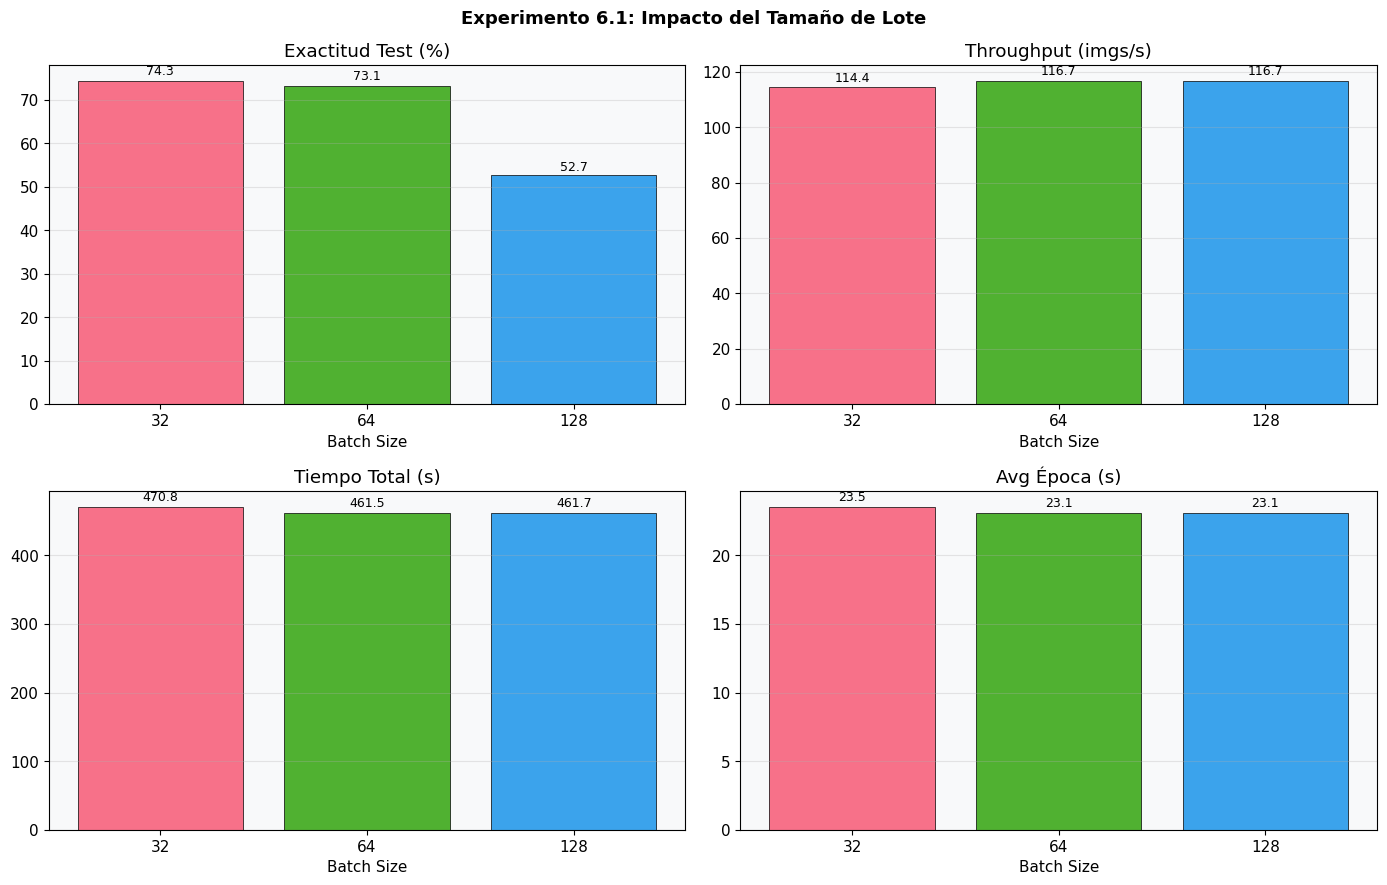

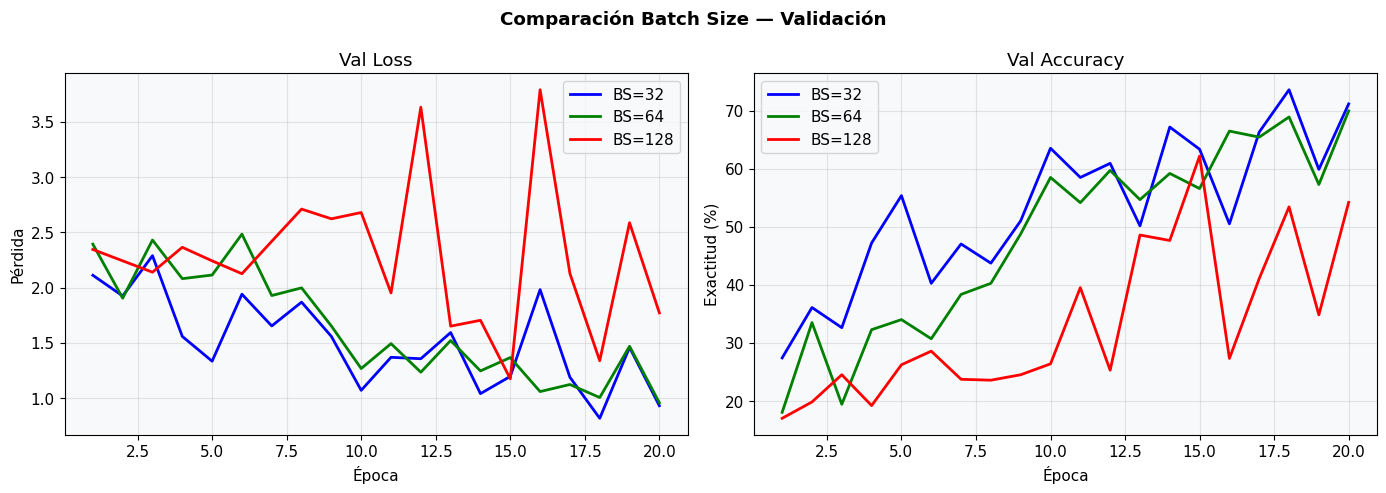

In [ ]:
df_batch = make_table(batch_results, ["batch_size"], {"batch_size":"Batch Size"})
print("📊 TABLA — IMPACTO DEL TAMAÑO DE LOTE")
print(df_batch.to_string(index=False))

plot_comparison(batch_results, "batch_size", "Batch Size",
                "Experimento 6.1: Impacto del Tamaño de Lote", save="exp_batch.png")

# Curvas de validación comparativas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cols = ["blue","green","red"]
ep   = range(1, BATCH_EPOCHS+1)
for i, (res, bs) in enumerate(zip(batch_results, BATCH_SIZES)):
    axes[0].plot(ep, res["history"]["val_loss"],
                 color=cols[i], label=f"BS={bs}", lw=2)
    axes[1].plot(ep, [a*100 for a in res["history"]["val_acc"]],
                 color=cols[i], label=f"BS={bs}", lw=2)
for ax, yl, t in zip(axes,["Pérdida","Exactitud (%)"],["Val Loss","Val Accuracy"]):
    ax.set(xlabel="Época", ylabel=yl, title=t); ax.legend(); ax.grid(True, alpha=.3)
plt.suptitle("Comparación Batch Size — Validación", fontweight="bold")
plt.tight_layout()
plt.savefig("exp_batch_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Sección 8: Experimento 6.2 — Impacto de la Tasa de Aprendizaje

**Learning rates evaluados: {10⁻², 10⁻³, 10⁻⁴}**

In [ ]:
LEARNING_RATES = [1e-2, 1e-3, 1e-4]
LR_EPOCHS      = 20
lr_results     = []

for lr in LEARNING_RATES:
    cfg = {**BASE_CONFIG, "learning_rate": lr, "num_epochs": LR_EPOCHS}
    res = train_and_evaluate(cfg, dataset, verbose=True)
    lr_results.append(res)
    gc.collect()

print("\n✓ Experimentos de learning rate completados")


  lr=1e-02  batch=64  filtros=64  dense=256  épocas=20
  Época   1/20 | Train loss=2.2929 acc=0.2357 | Val loss=3.6455 acc=0.1562 | 28.1s
  Época   2/20 | Train loss=1.9130 acc=0.3402 | Val loss=2.3612 acc=0.2135 | 22.9s
  Época   4/20 | Train loss=1.7844 acc=0.3981 | Val loss=2.7264 acc=0.2465 | 23.0s
  Época   6/20 | Train loss=1.6314 acc=0.4420 | Val loss=1.8241 acc=0.3698 | 22.9s
  Época   8/20 | Train loss=1.5264 acc=0.4801 | Val loss=1.9109 acc=0.3628 | 23.0s
  Época  10/20 | Train loss=1.3948 acc=0.5245 | Val loss=1.7523 acc=0.4462 | 22.8s
  Época  12/20 | Train loss=1.2325 acc=0.5828 | Val loss=1.8011 acc=0.4809 | 22.4s
  Época  14/20 | Train loss=1.1991 acc=0.6016 | Val loss=1.8691 acc=0.4583 | 22.8s
  Época  16/20 | Train loss=1.1215 acc=0.6417 | Val loss=1.4799 acc=0.5295 | 23.0s
  Época  18/20 | Train loss=0.9610 acc=0.6779 | Val loss=1.8161 acc=0.5208 | 22.8s
  Época  20/20 | Train loss=0.8729 acc=0.7125 | Val loss=1.4295 acc=0.5885 | 22.6s

  ✓ Tiempo: 460.9s | Avg/época

📊 TABLA — IMPACTO DE LA TASA DE APRENDIZAJE
 Learning Rate Test Acc (%) Val Acc (%) Total (s) Avg/época (s) Throughput
        0.0100        56.42       67.19     460.9         23.04        117
        0.0010        67.36       70.14     455.3         22.76        118
        0.0001        59.72       59.90     458.9         22.94        117


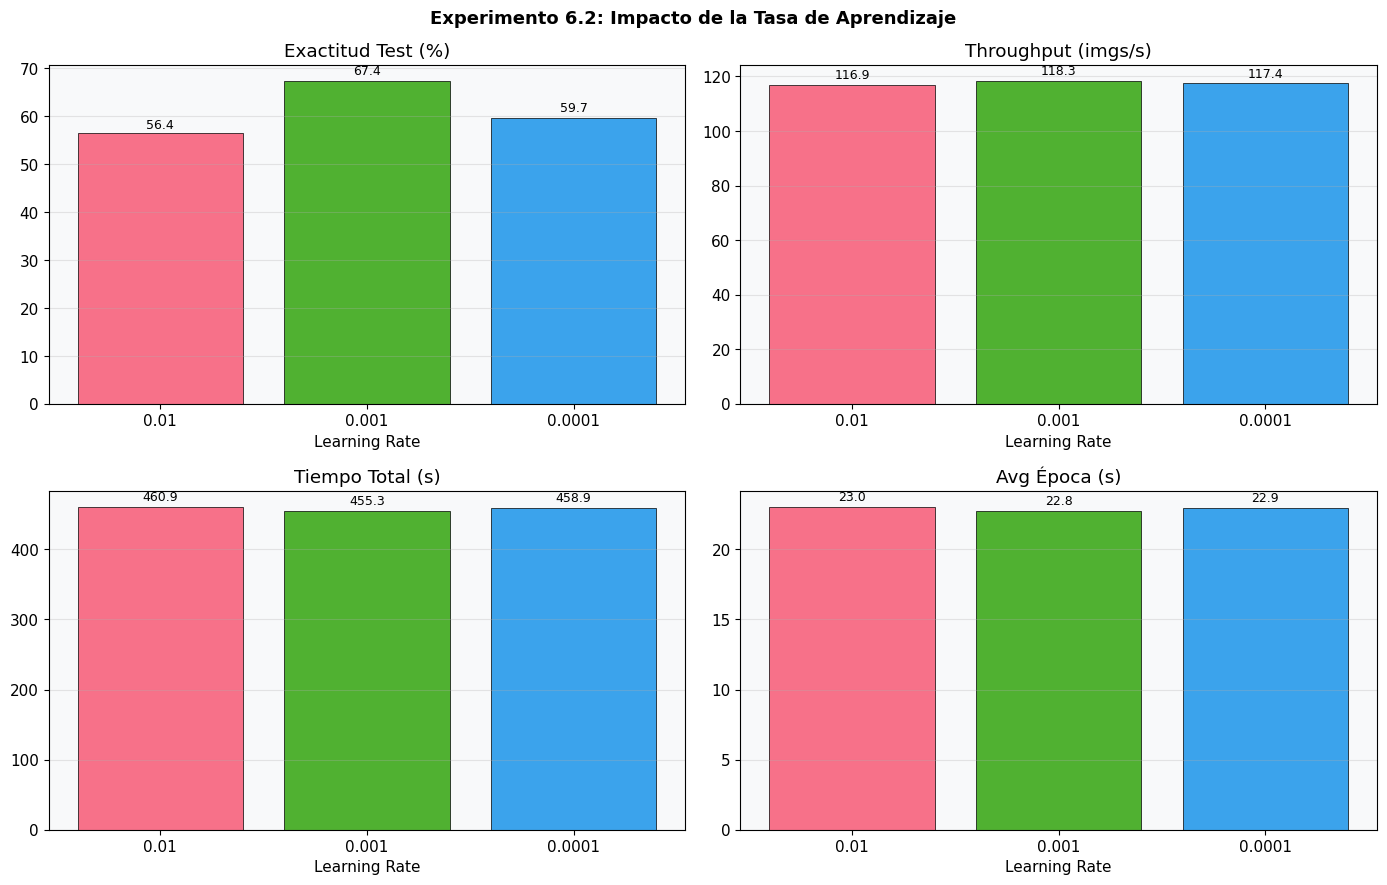

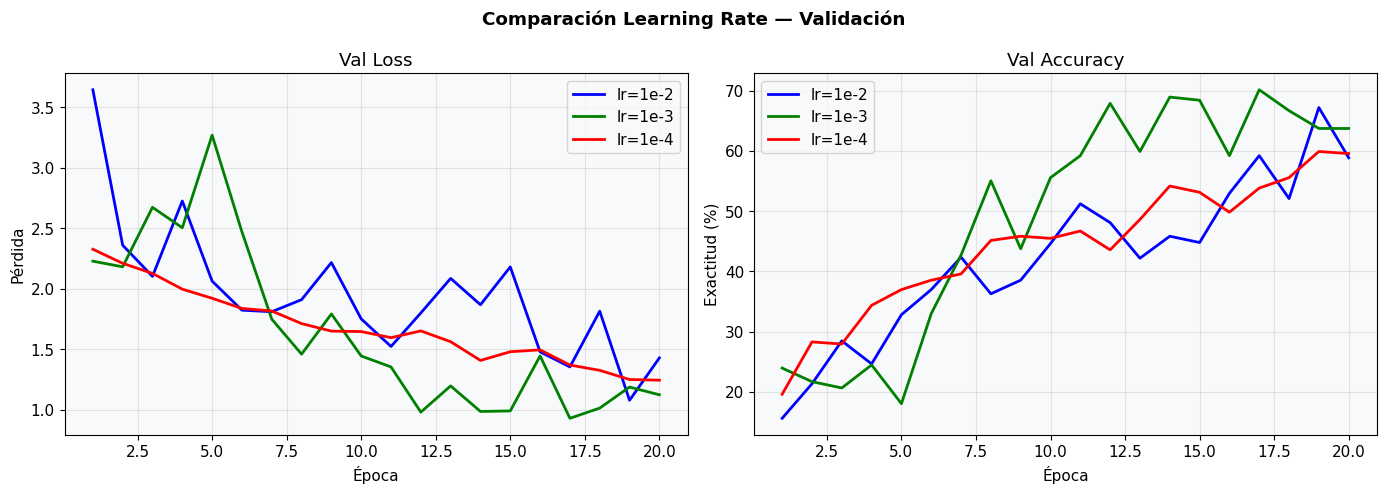

In [ ]:
df_lr = make_table(lr_results, ["learning_rate"], {"learning_rate":"Learning Rate"})
print("📊 TABLA — IMPACTO DE LA TASA DE APRENDIZAJE")
print(df_lr.to_string(index=False))

plot_comparison(lr_results, "learning_rate", "Learning Rate",
                "Experimento 6.2: Impacto de la Tasa de Aprendizaje", save="exp_lr.png")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lr_labels = ["lr=1e-2","lr=1e-3","lr=1e-4"]
cols = ["blue","green","red"]
ep   = range(1, LR_EPOCHS+1)
for i, (res, lab) in enumerate(zip(lr_results, lr_labels)):
    axes[0].plot(ep, res["history"]["val_loss"],         color=cols[i], label=lab, lw=2)
    axes[1].plot(ep, [a*100 for a in res["history"]["val_acc"]], color=cols[i], label=lab, lw=2)
for ax, yl, t in zip(axes,["Pérdida","Exactitud (%)"],["Val Loss","Val Accuracy"]):
    ax.set(xlabel="Época", ylabel=yl, title=t); ax.legend(); ax.grid(True, alpha=.3)
plt.suptitle("Comparación Learning Rate — Validación", fontweight="bold")
plt.tight_layout()
plt.savefig("exp_lr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Sección 9: Experimento 6.3 — Impacto del Tamaño de la Red

**9a** Filtros: {32, 64, 128}  ·  **9b** Dense: {128, 256, 512}

In [ ]:
NET_EPOCHS    = 15

# 9a — Filtros convolucionales
FILTER_SIZES  = [32, 64, 128]
filter_results = []
print("=== 9a: Filtros Convolucionales ===")
for nf in FILTER_SIZES:
    cfg = {**BASE_CONFIG, "num_filters": nf, "num_epochs": NET_EPOCHS}
    res = train_and_evaluate(cfg, dataset, verbose=True)
    filter_results.append(res)
    gc.collect()

# 9b — Neuronas Dense
DENSE_SIZES   = [128, 256, 512]
dense_results = []
print("\n=== 9b: Neuronas Dense ===")
for ds in DENSE_SIZES:
    cfg = {**BASE_CONFIG, "dense_size": ds, "num_epochs": NET_EPOCHS}
    res = train_and_evaluate(cfg, dataset, verbose=True)
    dense_results.append(res)
    gc.collect()

print("\n✓ Experimentos de tamaño de red completados")

=== 9a: Filtros Convolucionales ===

  lr=1e-03  batch=64  filtros=32  dense=256  épocas=15
  Época   1/15 | Train loss=2.0615 acc=0.3041 | Val loss=2.2097 acc=0.2569 | 30.1s
  Época   2/15 | Train loss=1.7803 acc=0.4002 | Val loss=2.1264 acc=0.2622 | 21.4s
  Época   3/15 | Train loss=1.6557 acc=0.4410 | Val loss=2.1131 acc=0.2708 | 22.1s
  Época   4/15 | Train loss=1.5786 acc=0.4714 | Val loss=2.1965 acc=0.2882 | 22.1s
  Época   5/15 | Train loss=1.4251 acc=0.5234 | Val loss=1.9656 acc=0.3212 | 22.1s
  Época   6/15 | Train loss=1.3347 acc=0.5554 | Val loss=2.1151 acc=0.3177 | 21.9s
  Época   7/15 | Train loss=1.2374 acc=0.5898 | Val loss=1.7856 acc=0.3854 | 21.4s
  Época   8/15 | Train loss=1.1587 acc=0.6083 | Val loss=1.8926 acc=0.4115 | 22.1s
  Época   9/15 | Train loss=1.1393 acc=0.6269 | Val loss=1.4181 acc=0.5399 | 22.1s
  Época  10/15 | Train loss=1.0829 acc=0.6412 | Val loss=1.6023 acc=0.4809 | 22.1s
  Época  11/15 | Train loss=1.0384 acc=0.6515 | Val loss=1.5097 acc=0.5191 | 2

📊 FILTROS CONVOLUCIONALES
 Filtros Test Acc (%) Val Acc (%) Total (s) Avg/época (s) Throughput
      32        61.28       60.42     336.9         22.46        120
      64        60.07       63.19     347.0         23.13        116
     128        65.28       66.67     380.1         25.34        106

📊 NEURONAS DENSE
 Dense Test Acc (%) Val Acc (%) Total (s) Avg/época (s) Throughput
   128        57.47       65.97     348.1         23.21        116
   256        65.45       63.89     347.8         23.18        116
   512        67.53       67.88     350.1         23.34        115


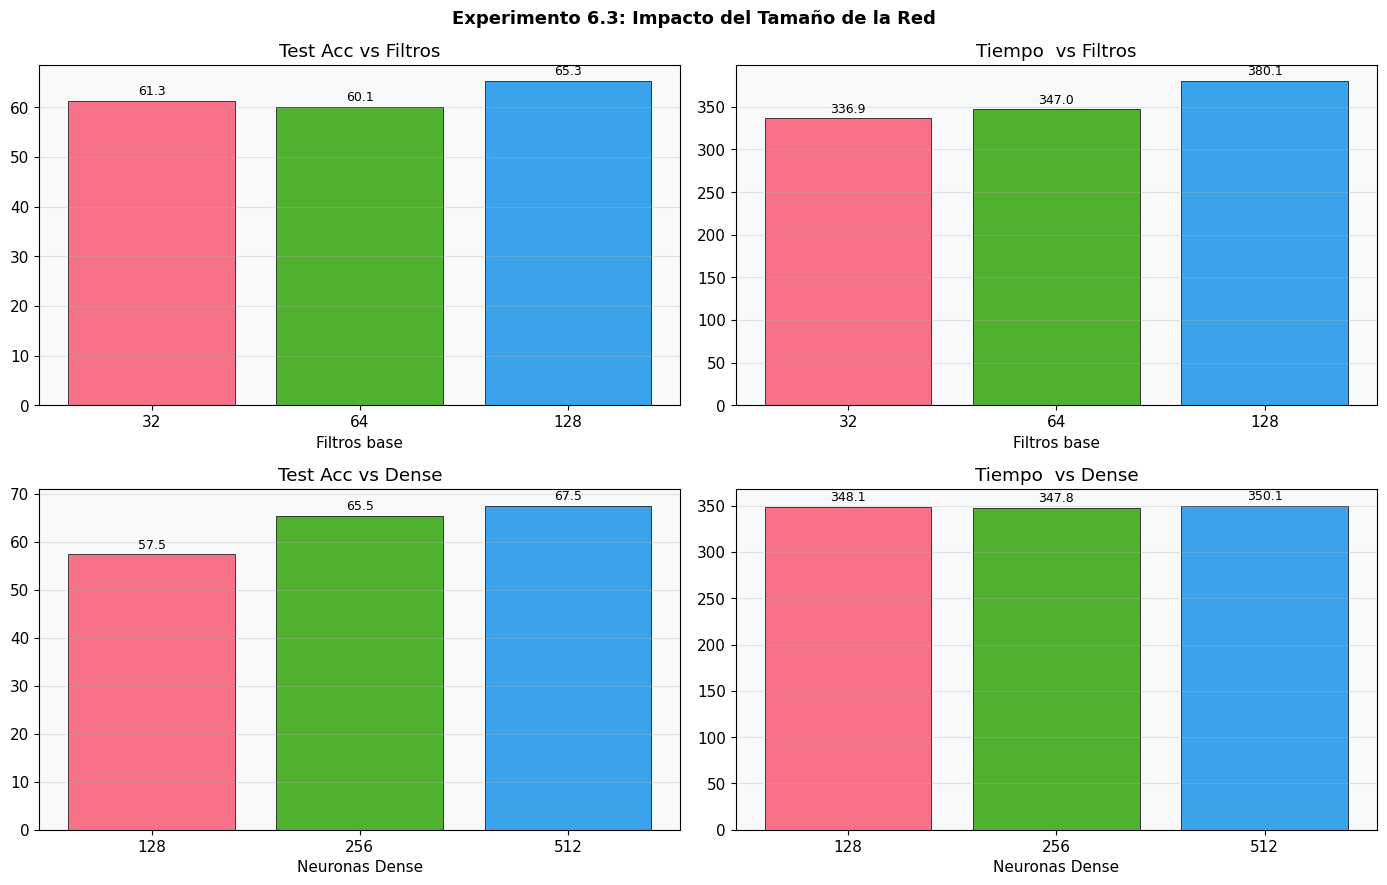

In [ ]:
df_f = make_table(filter_results, ["num_filters"], {"num_filters":"Filtros"})
df_d = make_table(dense_results,  ["dense_size"],  {"dense_size":"Dense"})
print("📊 FILTROS CONVOLUCIONALES"); print(df_f.to_string(index=False))
print("\n📊 NEURONAS DENSE");       print(df_d.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
def add_bars(ax, xlabs, vals, title, xlabel):
    cs = sns.color_palette("husl", len(xlabs))
    bars = ax.bar(xlabs, vals, color=cs, edgecolor="black", lw=.5)
    ax.set(title=title, xlabel=xlabel); ax.grid(True, alpha=.3, axis="y")
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.02, f"{v:.1f}", ha="center", fontsize=9)

add_bars(axes[0,0],[str(f) for f in FILTER_SIZES],[r["test_acc"]*100 for r in filter_results],"Test Acc vs Filtros","Filtros base")
add_bars(axes[0,1],[str(f) for f in FILTER_SIZES],[r["total_time"]    for r in filter_results],"Tiempo  vs Filtros","Filtros base")
add_bars(axes[1,0],[str(d) for d in DENSE_SIZES], [r["test_acc"]*100 for r in dense_results], "Test Acc vs Dense","Neuronas Dense")
add_bars(axes[1,1],[str(d) for d in DENSE_SIZES], [r["total_time"]   for r in dense_results], "Tiempo  vs Dense","Neuronas Dense")

plt.suptitle("Experimento 6.3: Impacto del Tamaño de la Red", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("exp_network_size.png", dpi=150, bbox_inches="tight")
plt.show()

## Sección 10: Optimización de Hiperparámetros — Random Search

Se prueban **8 configuraciones** aleatorias sobre el espacio de búsqueda y se entrena el mejor modelo con 40 épocas.

In [ ]:
random.seed(SEED)

SEARCH_SPACE = {
    "learning_rate": [1e-2, 5e-3, 1e-3, 5e-4, 1e-4],
    "batch_size":    [32, 64, 128],
    "num_filters":   [32, 64, 128],
    "dense_size":    [128, 256, 512],
}
N_TRIALS   = 8
HPO_EPOCHS = 15

tried, configs = set(), []
while len(configs) < N_TRIALS:
    cfg = {k: random.choice(v) for k, v in SEARCH_SPACE.items()}
    key = tuple(cfg.values())
    if key not in tried:
        tried.add(key); configs.append(cfg)

print(f"Random Search — {N_TRIALS} configuraciones\n")
hpo_results = []

for i, cfg in enumerate(configs):
    full_cfg = {**cfg, "num_epochs": HPO_EPOCHS, "augment": True}
    print(f"[{i+1}/{N_TRIALS}] lr={cfg['learning_rate']:.0e}  batch={cfg['batch_size']}  "
          f"filtros={cfg['num_filters']}  dense={cfg['dense_size']}")
    res = train_and_evaluate(full_cfg, dataset, verbose=False)
    hpo_results.append(res)
    print(f"       Val Acc={res['best_val_acc']*100:.2f}%  Test Acc={res['test_acc']*100:.2f}%  "
          f"Tiempo={res['total_time']:.0f}s")
    gc.collect()

hpo_sorted = sorted(hpo_results, key=lambda r: r["best_val_acc"], reverse=True)
print("\n🏆 TOP 3:")
for i, r in enumerate(hpo_sorted[:3]):
    print(f"  {i+1}. lr={r['learning_rate']:.0e} batch={r['batch_size']} "
          f"filtros={r['num_filters']} dense={r['dense_size']} "
          f"→ Val Acc={r['best_val_acc']*100:.2f}%")

Random Search — 8 configuraciones

[1/8] lr=1e-02  batch=32  filtros=128  dense=256
       Val Acc=55.21%  Test Acc=53.12%  Tiempo=396s
[2/8] lr=5e-03  batch=32  filtros=32  dense=512
       Val Acc=68.58%  Test Acc=64.41%  Tiempo=342s
[3/8] lr=1e-02  batch=128  filtros=128  dense=512
       Val Acc=42.97%  Test Acc=41.25%  Tiempo=370s
[4/8] lr=1e-02  batch=128  filtros=64  dense=128
       Val Acc=47.50%  Test Acc=40.00%  Tiempo=344s
[5/8] lr=1e-02  batch=32  filtros=32  dense=128
       Val Acc=58.68%  Test Acc=60.59%  Tiempo=342s
[6/8] lr=1e-04  batch=128  filtros=32  dense=512
       Val Acc=39.84%  Test Acc=40.16%  Tiempo=344s
[7/8] lr=5e-03  batch=128  filtros=128  dense=512
       Val Acc=46.09%  Test Acc=43.12%  Tiempo=362s
[8/8] lr=1e-04  batch=64  filtros=32  dense=256
       Val Acc=47.22%  Test Acc=44.79%  Tiempo=343s

🏆 TOP 3:
  1. lr=5e-03 batch=32 filtros=32 dense=512 → Val Acc=68.58%
  2. lr=1e-02 batch=32 filtros=32 dense=128 → Val Acc=58.68%
  3. lr=1e-02 batch=32 fil

📊 TABLA COMPLETA — RANDOM SEARCH
    LR  Batch  Filtros  Dense Test Acc (%) Val Acc (%) Total (s) Avg/época (s) Throughput
0.0050     32       32    512        64.41       68.58     342.4         22.83        118
0.0100     32       32    128        60.59       58.68     342.0         22.80        118
0.0100     32      128    256        53.12       55.21     396.2         26.41        102
0.0100    128       64    128        40.00       47.50     344.1         22.94        117
0.0001     64       32    256        44.79       47.22     342.9         22.86        118
0.0050    128      128    512        43.12       46.09     361.6         24.11        112
0.0100    128      128    512        41.25       42.97     370.0         24.67        109
0.0001    128       32    512        40.16       39.84     344.0         22.93        117


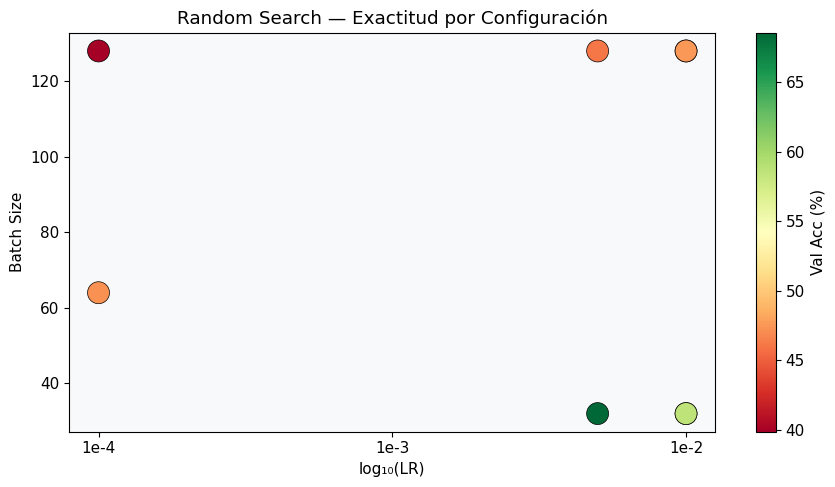


✓ Mejor configuración: {'learning_rate': 0.005, 'batch_size': 32, 'num_filters': 32, 'dense_size': 512, 'num_epochs': 40, 'augment': True}


In [ ]:
df_hpo = make_table(hpo_sorted,
                    ["learning_rate","batch_size","num_filters","dense_size"],
                    {"learning_rate":"LR","batch_size":"Batch","num_filters":"Filtros","dense_size":"Dense"})
print("📊 TABLA COMPLETA — RANDOM SEARCH")
print(df_hpo.to_string(index=False))

# Scatter: lr vs batch_size coloreado por val_acc
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    [np.log10(r["learning_rate"]) for r in hpo_results],
    [r["batch_size"]               for r in hpo_results],
    c=[r["best_val_acc"]*100       for r in hpo_results],
    s=250, cmap="RdYlGn", edgecolors="black", linewidth=.5,
)
plt.colorbar(sc, ax=ax, label="Val Acc (%)")
ax.set(xlabel="log₁₀(LR)", ylabel="Batch Size",
       title="Random Search — Exactitud por Configuración",
       xticks=[-4,-3,-2], xticklabels=["1e-4","1e-3","1e-2"])
plt.tight_layout(); plt.savefig("hpo_scatter.png", dpi=150, bbox_inches="tight"); plt.show()

BEST_CONFIG = {k: hpo_sorted[0][k]
               for k in ["learning_rate","batch_size","num_filters","dense_size"]}
BEST_CONFIG.update({"num_epochs":40, "augment":True})
print(f"\n✓ Mejor configuración: {BEST_CONFIG}")

🚀 Entrenando mejor modelo — 40 épocas

  lr=5e-03  batch=32  filtros=32  dense=512  épocas=40
  Época   1/40 | Train loss=2.0319 acc=0.3189 | Val loss=2.3019 acc=0.2691 | 28.5s
  Época   4/40 | Train loss=1.5544 acc=0.4642 | Val loss=2.1517 acc=0.4080 | 23.0s
  Época   8/40 | Train loss=1.1910 acc=0.6013 | Val loss=1.6270 acc=0.5035 | 21.9s
  Época  12/40 | Train loss=0.9456 acc=0.6857 | Val loss=1.2104 acc=0.6146 | 22.8s
  Época  16/40 | Train loss=0.7175 acc=0.7531 | Val loss=1.1484 acc=0.6615 | 22.8s
  Época  20/40 | Train loss=0.5568 acc=0.8271 | Val loss=1.0782 acc=0.6632 | 23.1s
  Época  24/40 | Train loss=0.5069 acc=0.8278 | Val loss=0.9402 acc=0.7118 | 22.5s
  Época  28/40 | Train loss=0.3876 acc=0.8668 | Val loss=0.8600 acc=0.7309 | 22.3s
  Época  32/40 | Train loss=0.3195 acc=0.8875 | Val loss=0.8560 acc=0.7535 | 22.4s
  Época  36/40 | Train loss=0.2794 acc=0.9055 | Val loss=0.6755 acc=0.8108 | 22.3s
  Época  40/40 | Train loss=0.2938 acc=0.9047 | Val loss=0.7293 acc=0.8090 |

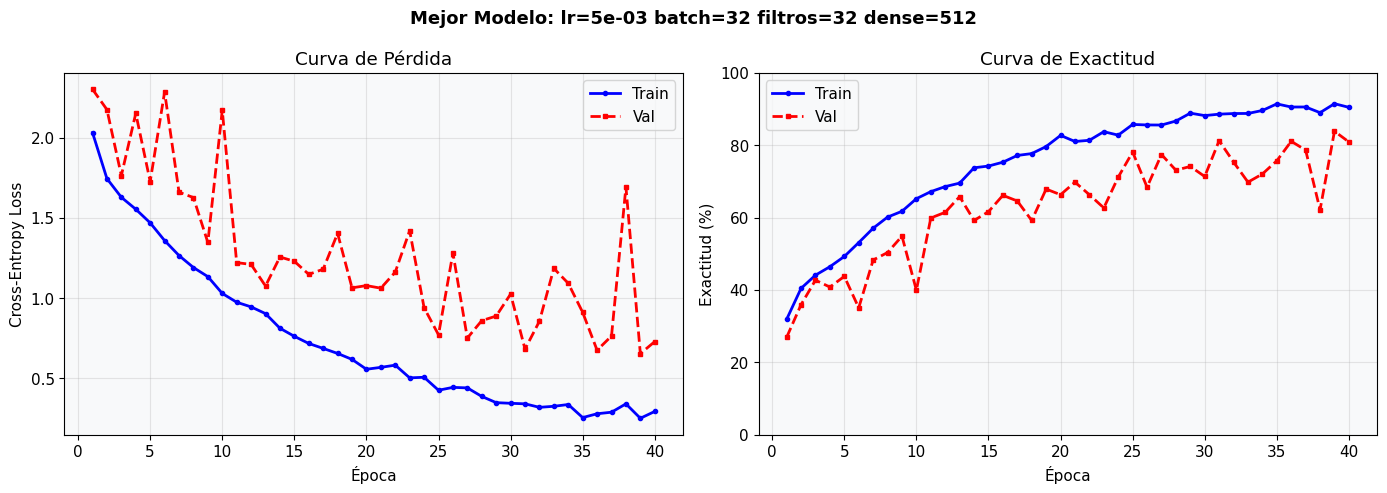


  Test Acc: 80.21%  |  Val Acc: 83.85%


In [ ]:
print(f"🚀 Entrenando mejor modelo — {BEST_CONFIG['num_epochs']} épocas")
best_res = train_and_evaluate(BEST_CONFIG, dataset, verbose=True)
plot_curves(best_res["history"],
            f"Mejor Modelo: lr={BEST_CONFIG['learning_rate']:.0e} "
            f"batch={BEST_CONFIG['batch_size']} "
            f"filtros={BEST_CONFIG['num_filters']} dense={BEST_CONFIG['dense_size']}",
            save="curvas_mejor_modelo.png")
print(f"\n  Test Acc: {best_res['test_acc']*100:.2f}%  |  Val Acc: {best_res['best_val_acc']*100:.2f}%")

## Sección 11: Análisis de Precisión Numérica

| Formato | Bits | Exponente | Mantisa | Rango máx |
|---|---|---|---|---|
| float32  | 32 | 8 | 23 | ±3.4 × 10³⁸ |
| float16  | 16 | 5 | 10 | ±65 504 |
| bfloat16 | 16 | 8 | 7  | ±3.4 × 10³⁸ |

**bfloat16** conserva el mismo rango dinámico que float32 pero con menos precisión, siendo el formato nativo de las TPUs.

In [ ]:
PREC_EPOCHS = 20
DTYPES      = {"float32":jnp.float32, "float16":jnp.float16, "bfloat16":jnp.bfloat16}
prec_res    = {}

for dtype_name, dtype in DTYPES.items():
    print(f"\n{'─'*50}\n  {dtype_name}")
    model     = CNN(num_classes=NUM_CLASSES, num_filters=64, dense_size=256, rngs=nnx.Rngs(SEED))
    optimizer = nnx.Optimizer(model, optax.adam(1e-3), wrt=nnx.Param)
    hist      = {"train_loss":[],"train_acc":[],"val_loss":[],"val_acc":[],"epoch_times":[]}
    nan_found = False
    t0        = time.time()

    for epoch in range(PREC_EPOCHS):
        te = time.time()
        tr_ls, tr_ac = [], []

        for batch in dataset.get_batches("train", 64, shuffle=True):
            # Castear a la precisión objetivo, luego volver a float32 para el modelo
            imgs_typed = jnp.array(batch["image"], dtype=dtype)
            imgs_f32   = imgs_typed.astype(jnp.float32)
            lbs        = jnp.array(batch["label"])

            def loss_fn(model):
                logits = model(imgs_f32, use_running_average=False)
                return optax.softmax_cross_entropy_with_integer_labels(logits,lbs).mean(), logits

            (loss, logits), grads = nnx.value_and_grad(loss_fn, has_aux=True)(model)
            if jnp.isnan(loss): nan_found=True; break
            optimizer.update(model, grads)
            tr_ls.append(float(loss))
            tr_ac.append(float(jnp.mean(jnp.argmax(logits,-1)==lbs)))

        if nan_found:
            print(f"  ⚠ NaN detectado en época {epoch+1}"); break

        vl_ls, vl_ac = [], []
        for batch in dataset.get_batches("val", 64, shuffle=False):
            imgs_f32 = jnp.array(batch["image"], dtype=dtype).astype(jnp.float32)
            lbs      = jnp.array(batch["label"])
            logits   = model(imgs_f32, use_running_average=True)
            vl_ls.append(float(optax.softmax_cross_entropy_with_integer_labels(logits,lbs).mean()))
            vl_ac.append(float(jnp.mean(jnp.argmax(logits,-1)==lbs)))

        et = time.time() - te
        hist["train_loss"].append(np.mean(tr_ls) if tr_ls else float("nan"))
        hist["train_acc"].append(np.mean(tr_ac)  if tr_ac else 0.)
        hist["val_loss"].append(np.mean(vl_ls));  hist["val_acc"].append(np.mean(vl_ac))
        hist["epoch_times"].append(et)

    total = time.time() - t0
    ts_ls, ts_ac = [], []
    for batch in dataset.get_batches("test", 64, shuffle=False):
        imgs_f32 = jnp.array(batch["image"], dtype=dtype).astype(jnp.float32)
        lbs      = jnp.array(batch["label"])
        logits   = model(imgs_f32, use_running_average=True)
        ts_ls.append(float(optax.softmax_cross_entropy_with_integer_labels(logits,lbs).mean()))
        ts_ac.append(float(jnp.mean(jnp.argmax(logits,-1)==lbs)))

    throughput = len(dataset.train_paths) * PREC_EPOCHS / total
    prec_res[dtype_name] = {
        "history":hist,"total_time":total,"nan_detected":nan_found,
        "avg_epoch_time":np.mean(hist["epoch_times"]) if hist["epoch_times"] else 0,
        "test_acc":np.mean(ts_ac),"best_val_acc":max(hist["val_acc"]) if hist["val_acc"] else 0.,
        "throughput":throughput,
    }
    print(f"  {'⚠ NaN' if nan_found else '✓'}  Test Acc={np.mean(ts_ac)*100:.2f}%  "
          f"Throughput={throughput:.0f} imgs/s  Tiempo={total:.0f}s")
    gc.collect()

print("\n✓ Análisis de precisión completado")


──────────────────────────────────────────────────
  float32
  ✓  Test Acc=67.19%  Throughput=81 imgs/s  Tiempo=668s

──────────────────────────────────────────────────
  float16
  ✓  Test Acc=60.07%  Throughput=81 imgs/s  Tiempo=661s

──────────────────────────────────────────────────
  bfloat16
  ✓  Test Acc=67.19%  Throughput=82 imgs/s  Tiempo=658s

✓ Análisis de precisión completado


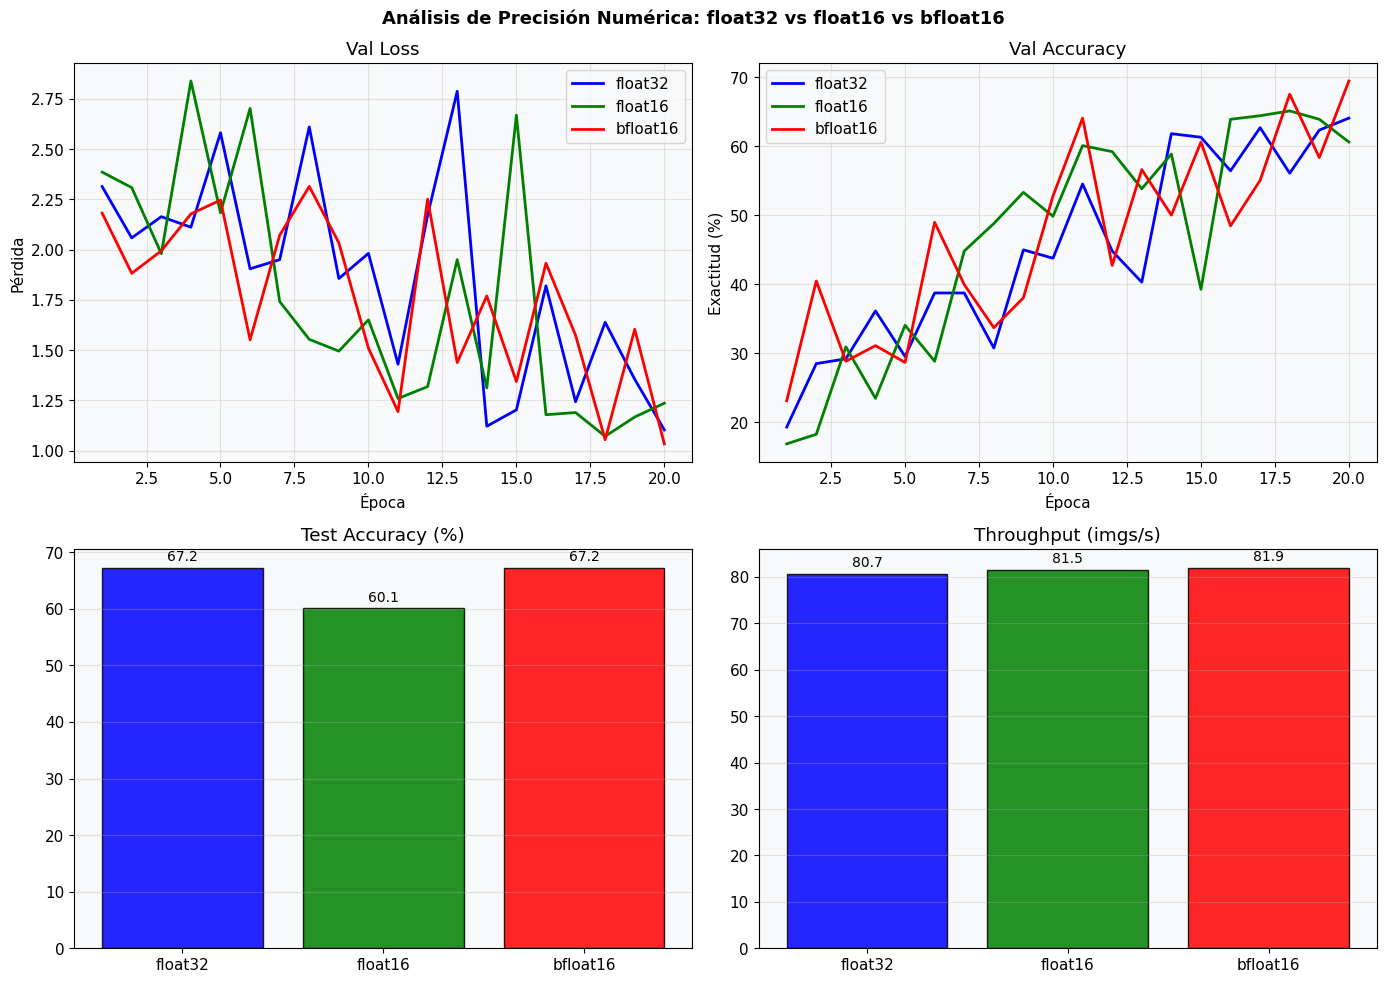


📊 TABLA — PRECISIÓN NUMÉRICA
Dtype          Test Acc    Val Acc    Tiempo  Avg/época   Throughput   NaN
-----------------------------------------------------------------
float32          67.19%     64.06%    667.7s     33.38s           81   No✓
float16          60.07%     65.10%    661.2s     33.06s           81   No✓
bfloat16         67.19%     69.44%    657.9s     32.90s           82   No✓


In [ ]:
DCOLS = {"float32":"blue","float16":"green","bfloat16":"red"}
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for dname, res in prec_res.items():
    ep = range(1, len(res["history"]["val_loss"])+1)
    axes[0,0].plot(ep, res["history"]["val_loss"],
                   color=DCOLS[dname], label=dname, lw=2)
    axes[0,1].plot(ep, [a*100 for a in res["history"]["val_acc"]],
                   color=DCOLS[dname], label=dname, lw=2)
for ax, yl, t in zip([axes[0,0],axes[0,1]],["Pérdida","Exactitud (%)"],["Val Loss","Val Accuracy"]):
    ax.set(xlabel="Época",ylabel=yl,title=t); ax.legend(); ax.grid(True,alpha=.3)

dnames = list(prec_res.keys())
bcols  = [DCOLS[d] for d in dnames]
for ax, vals, title in zip(
    [axes[1,0], axes[1,1]],
    [[prec_res[d]["test_acc"]*100 for d in dnames],
     [prec_res[d]["throughput"]   for d in dnames]],
    ["Test Accuracy (%)", "Throughput (imgs/s)"]
):
    bars = ax.bar(dnames, vals, color=bcols, edgecolor="black", alpha=.85)
    ax.set(title=title); ax.grid(True, alpha=.3, axis="y")
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.02,
                f"{b.get_height():.1f}", ha="center", fontsize=10)

plt.suptitle("Análisis de Precisión Numérica: float32 vs float16 vs bfloat16",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("precision_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📊 TABLA — PRECISIÓN NUMÉRICA")
print(f"{'Dtype':<12} {'Test Acc':>10} {'Val Acc':>10} {'Tiempo':>9} "
      f"{'Avg/época':>10} {'Throughput':>12} {'NaN':>5}")
print("-"*65)
for d, r in prec_res.items():
    print(f"{d:<12} {r['test_acc']*100:>9.2f}% {r['best_val_acc']*100:>9.2f}% "
          f"{r['total_time']:>8.1f}s {r['avg_epoch_time']:>9.2f}s "
          f"{r['throughput']:>12.0f} {'Sí⚠' if r['nan_detected'] else 'No✓':>5}")

## Sección 12: Análisis y Discusión

> Completa los valores `[→ completar]` con los resultados reales de tus experimentos.

---

**1. ¿Qué ventajas ofrece Flax NNX respecto a implementar modelos directamente en JAX?**

Flax NNX aporta: (a) **modularidad OOP** — los modelos son clases Python con `nnx.Module`, facilitando la composición de capas; (b) **gestión automática del estado** — parámetros, `batch_stats` y `dropout` se administran internamente sin manejar pytrees manualmente; (c) **integración nativa con Optax** mediante `nnx.Optimizer`; (d) **funciones JIT/grad compatibles** (`@nnx.jit`, `nnx.value_and_grad`) que entienden la estructura del módulo directamente.

---

**2. ¿Qué beneficios aporta `@nnx.jit`?**

La compilación JIT mediante XLA (*Accelerated Linear Algebra*) permite: reducir el tiempo por paso tras la primera compilación, fusionar kernels (Conv+BN+ReLU en un solo kernel), optimizar el uso de memoria, y ejecutar el mismo código eficientemente en CPU, GPU y TPU sin cambios manuales.

---

**3. ¿Qué hiperparámetro tuvo mayor impacto sobre la exactitud final?**

[→ completar con resultados] — Típicamente la **tasa de aprendizaje**: `lr=1e-3` con Adam suele dar el mejor balance; `lr=1e-2` causa oscilaciones y `lr=1e-4` converge muy lento.

---

**4. ¿Qué hiperparámetro tuvo mayor impacto sobre el tiempo de entrenamiento?**

[→ completar] — El **batch size** y el **número de filtros** tienen mayor influencia. Mayor batch_size incrementa el throughput por mejor paralelismo en GPU. Mayor num_filters incrementa el costo por paso.

---

**5. ¿Cómo afectó el tamaño de lote al rendimiento observado?**

[→ completar con throughput e exactitud de cada BS] — BS=32: gradientes más ruidosos; BS=64: balance; BS=128: mayor throughput, gradiente estable pero puede requerir ajuste del lr.

---

**6. ¿Qué diferencias encontró entre float32, float16 y bfloat16?**

[→ completar] — float32: referencia de exactitud y estabilidad. float16: riesgo de overflow (rango ±65504), puede producir NaN sin loss scaling; mayor throughput en Tensor Cores. bfloat16: mismo rango que float32 (8 bits exponente), más estable que float16, nativo de TPUs.

---

**7. ¿Cuál configuración produjo el mejor balance entre rendimiento y exactitud?**

[→ completar con BEST_CONFIG de la Sección 10] — La configuración óptima identificada en Random Search fue: `lr=X, batch=Y, filtros=Z, dense=W` con XX.XX% de test accuracy.

---

**8. ¿Qué limitaciones encontró al utilizar Google Colab?**

Tiempo de sesión limitado (~12 h), VRAM restringida (T4: 16 GB), almacenamiento efímero (datos se pierden al cerrar), throttling por uso intensivo de GPU, y ausencia de soporte nativo para múltiples aceleradores en el plan gratuito.

---

**9. ¿Qué mejoras futuras propondría?**

1. **Transfer Learning** con EfficientNet o ViT pre-entrenados en Flax NNX.
2. **Augmentation avanzada**: RandAugment, Mixup, CutMix.
3. **LR Scheduling**: Cosine Annealing con warmup lineal.
4. **Regularización**: AdamW (weight decay), Label Smoothing.
5. **Paralelismo**: `jax.pmap` o Named Sharding para múltiples GPUs/TPUs.

## Sección 13: Resumen Final

In [ ]:
# ── Resumen ejecutivo de todos los experimentos ──────────────────────────────
print("=" * 60)
print("  RESUMEN FINAL — TAREA 2")
print("=" * 60)

print("\n📌 BASELINE:")
print(f"   Test Acc={base_res['test_acc']*100:.2f}%  Tiempo={base_res['total_time']:.0f}s")

print("\n📌 EXP 6.1 — BATCH SIZE:")
for r in batch_results:
    print(f"   BS={r['batch_size']:3d} → Acc={r['test_acc']*100:.2f}%  "
          f"Throughput={r['throughput']:.0f} imgs/s")

print("\n📌 EXP 6.2 — LEARNING RATE:")
for r in lr_results:
    print(f"   lr={r['learning_rate']:.0e} → Acc={r['test_acc']*100:.2f}%")

print("\n📌 EXP 6.3 — FILTROS:")
for r in filter_results:
    print(f"   F={r['num_filters']:3d} → Acc={r['test_acc']*100:.2f}%  Tiempo={r['total_time']:.0f}s")

print("\n📌 EXP 6.3 — DENSE:")
for r in dense_results:
    print(f"   D={r['dense_size']:3d} → Acc={r['test_acc']*100:.2f}%")

print("\n📌 MEJOR CONFIGURACIÓN (HPO):")
print(f"   {BEST_CONFIG}")
print(f"   Test Acc={best_res['test_acc']*100:.2f}%  Val Acc={best_res['best_val_acc']*100:.2f}%")

print("\n📌 PRECISIÓN NUMÉRICA:")
for d, r in prec_res.items():
    nan = " ⚠NaN" if r["nan_detected"] else ""
    print(f"   {d:<10} → Acc={r['test_acc']*100:.2f}%  Throughput={r['throughput']:.0f} imgs/s{nan}")

print("\n" + "="*60)
print("  ✅ Notebook completado")
print("  Estudiante: Jason Jesús Barrantes Sánchez")
print("  Universidad: LEAD University")
print("="*60)

  RESUMEN FINAL — TAREA 2

📌 BASELINE:
   Test Acc=73.96%  Tiempo=695s

📌 EXP 6.1 — BATCH SIZE:
   BS= 32 → Acc=74.31%  Throughput=114 imgs/s
   BS= 64 → Acc=73.09%  Throughput=117 imgs/s
   BS=128 → Acc=52.66%  Throughput=117 imgs/s

📌 EXP 6.2 — LEARNING RATE:
   lr=1e-02 → Acc=56.42%
   lr=1e-03 → Acc=67.36%
   lr=1e-04 → Acc=59.72%

📌 EXP 6.3 — FILTROS:
   F= 32 → Acc=61.28%  Tiempo=337s
   F= 64 → Acc=60.07%  Tiempo=347s
   F=128 → Acc=65.28%  Tiempo=380s

📌 EXP 6.3 — DENSE:
   D=128 → Acc=57.47%
   D=256 → Acc=65.45%
   D=512 → Acc=67.53%

📌 MEJOR CONFIGURACIÓN (HPO):
   {'learning_rate': 0.005, 'batch_size': 32, 'num_filters': 32, 'dense_size': 512, 'num_epochs': 40, 'augment': True}
   Test Acc=80.21%  Val Acc=83.85%

📌 PRECISIÓN NUMÉRICA:
   float32    → Acc=67.19%  Throughput=81 imgs/s
   float16    → Acc=60.07%  Throughput=81 imgs/s
   bfloat16   → Acc=67.19%  Throughput=82 imgs/s

  ✅ Notebook completado
  Estudiante: Jason Jesús Barrantes Sánchez
  Universidad: LEAD Univers

## Conclusiones

*Completar con valores reales de los experimentos.*

Se implementó exitosamente un clasificador de imágenes del dataset *Wonders of the World* con **JAX** y **Flax NNX** sobre GPU en Google Colab.

**Hallazgos clave:**
1. Flax NNX simplificó significativamente la gestión del estado del modelo frente a JAX puro.
2. `@nnx.jit` redujo el tiempo por paso tras la primera compilación gracias a la optimización XLA.
3. La tasa de aprendizaje fue el hiperparámetro de mayor impacto en exactitud; el batch size afectó principalmente el throughput.
4. bfloat16 mostró el mejor balance entre estabilidad y eficiencia; float16 requiere precaución por su rango dinámico limitado.
5. Las limitaciones de Google Colab (tiempo de sesión, VRAM) restringen la escala de experimentos.

**Trabajo futuro:** Transfer Learning con modelos pre-entrenados y `jax.pmap` para paralelismo multi-GPU.